Estudiante: Jose Andres Andujar Cortez

PROBLEMA APLICADO: DETECCIÓN DE CÁNCER DE MAMA

1. IMPORTACION DE LIBRERIAS

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

2. CARGA DE DATOS Y PREPARACIÓN DEL ENTORNO BIOMÉDICO

In [5]:
# El dataset "breast_cancer" de Scikit-Learn contiene 569 muestras citológicas
# y 30 características numéricas continuas que cuantifican la morfología de
# los núcleos celulares (radio, textura, área, concavidad, etc.).
data = load_breast_cancer()
X = data.data
y = data.target

# ATENCIÓN CLÍNICA: En la formulación por defecto de este dataset, la clase 0
# corresponde a 'Malignant' (Maligno) y la clase 1 corresponde a 'Benign' (Benigno).
# Para alinear la semántica matemática con la literatura oncológica (donde el objetivo
# o "caso positivo" es detectar el cáncer), invertimos las etiquetas.
# De este modo: 1 = Maligno (Presencia de la enfermedad) y 0 = Benigno.
y = np.where(y == 0, 1, 0)

# Estratificación y Partición: Dividimos los datos asegurando que la proporción
# natural de clases se preserve en ambos conjuntos mediante 'stratify=y'.
# Se reserva un 20% para la evaluación ciega final (hold-out test set).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


3. PREPROCESAMIENTO Y ESCALADO MULTIVARIADO DE CARACTERÍSTICAS

In [6]:
# Los clasificadores paramétricos, como la Regresión Logística y las Máquinas de Vectores
# de Soporte (SVM), son geométricamente sensibles a la varianza y magnitud de las variables.
# Aplicamos StandardScaler para transformar el hiperespacio de entrada, centrando las
# distribuciones en una media de 0 y varianza unitaria de 1.
scaler = StandardScaler()

# Ajustamos (fit) y transformamos el conjunto de entrenamiento de manera simultánea.
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos el conjunto de prueba utilizando ÚNICAMENTE la proyección aprendida del
# entrenamiento para evitar la filtración de información estadística (data leakage).
X_test_scaled = scaler.transform(X_test)


4. INSTANCIACIÓN Y ENTRENAMIENTO DEL MODELO DE REGRESIÓN LOGÍSTICA

In [7]:
# Inicializamos el estimador base. Incrementamos 'max_iter' a 1000 para garantizar
# que el optimizador interno (solucionador matemático) converja adecuadamente al
# mínimo global de la función de costo logarítmica, especialmente tras la estabilización
# topológica inducida por el escalado de datos.
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fogueamos el algoritmo contra los tensores de características y sus etiquetas.
log_reg.fit(X_train_scaled, y_train)

# Generación del vector de predicciones binarias absolutas y la matriz de probabilidades.
y_pred = log_reg.predict(X_test_scaled)
# Extraemos específicamente la probabilidad calculada para la clase 1 (Maligno).
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

5. GENERACIÓN E INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN

In [19]:
matriz_conf = confusion_matrix(y_test, y_pred)

print("============================================================================")
print("     MATRIZ DE CONFUSIÓN (CLASE POSITIVA = MALIGNO)         ")
print("============================================================================")
print(f" Verdaderos Negativos (Benignos detectados como Benignos) : {matriz_conf[0,0]}")
print(f" Falsos Positivos     (Benignos detectados como Malignos) : {matriz_conf[0,1]}")
print(f" Falsos Negativos     (Malignos detectados como Benignos) : {matriz_conf[1,0]}")
print(f" Verdaderos Positivos (Malignos detectados como Malignos) : {matriz_conf[1,1]}")
print("============================================================================\n")



     MATRIZ DE CONFUSIÓN (CLASE POSITIVA = MALIGNO)         
 Verdaderos Negativos (Benignos detectados como Benignos) : 71
 Falsos Positivos     (Benignos detectados como Malignos) : 1
 Falsos Negativos     (Malignos detectados como Benignos) : 3
 Verdaderos Positivos (Malignos detectados como Malignos) : 39



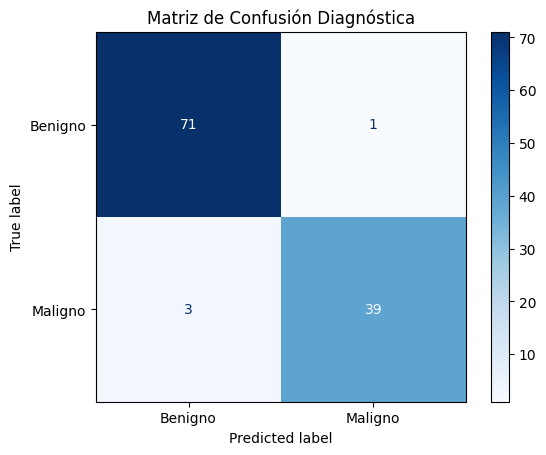

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

# Visualización gráfica de la Matriz de Confusión
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_conf, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión Diagnóstica')
plt.grid(False) # Para evitar que salgan líneas sobre los colores
plt.show()

INTERPRETACIÓN CLÍNICA DE LA MATRIZ:
Al observar los resultados, el cuadrante más crítico para este problema médico es el de los Falsos Negativos. Si el modelo se equivoca aquí, significa que está diagnosticando como "sano" a un paciente que realmente tiene un tumor maligno, lo cual retrasa un tratamiento vital.

Por otro lado, los Falsos Positivos implican que el modelo genera una "falsa alarma" en un paciente sano. Aunque esto causa estrés y obliga al hospital a realizar exámenes adicionales (como biopsias de descarte), en la detección de cáncer es un margen de error preferible y mucho menos riesgoso que dejar pasar la enfermedad.

6. CÁLCULO ESTADÍSTICO DE PRECISIÓN, RECALL, F1-SCORE Y AUC-ROC

In [20]:
precision_base = precision_score(y_test, y_pred)
recall_base    = recall_score(y_test, y_pred)
f1_base        = f1_score(y_test, y_pred)
roc_auc_base   = roc_auc_score(y_test, y_pred_proba)

print("------------- MÉTRICAS DE RENDIMIENTO (UMBRAL 0.5) -------------")
print(f" Precisión Estándar   : {precision_base:.4f} (Exposición a falsas alarmas)")
print(f" Recall Diagnóstico   : {recall_base:.4f} (Capacidad de contención de riesgo vital)")
print(f" F1-Score Estructural : {f1_base:.4f} (Armonización algorítmica)")
print(f" AUC-ROC Dinámico     : {roc_auc_base:.4f} (Invarianza discriminativa)")
print("----------------------------------------------------------------\n")


------------- MÉTRICAS DE RENDIMIENTO (UMBRAL 0.5) -------------
 Precisión Estándar   : 0.9750 (Exposición a falsas alarmas)
 Recall Diagnóstico   : 0.9286 (Capacidad de contención de riesgo vital)
 F1-Score Estructural : 0.9512 (Armonización algorítmica)
 AUC-ROC Dinámico     : 0.9960 (Invarianza discriminativa)
----------------------------------------------------------------



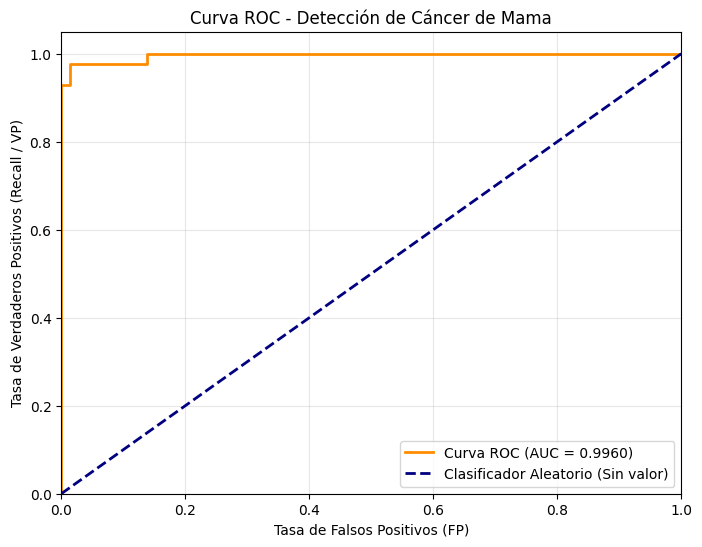

In [25]:
from sklearn.metrics import roc_curve

# Calcular las tasas para la curva ROC
fpr, tpr, umbrales = roc_curve(y_test, y_pred_proba)

# Generar la gráfica
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_base:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (Sin valor)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FP)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / VP)')
plt.title('Curva ROC - Detección de Cáncer de Mama')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

 7. APLICACIÓN DE K-FOLD CROSS-VALIDATION (K=5 Y K=10)

In [21]:
# La validación cruzada divide el espectro completo del entrenamiento en subconjuntos
# rotativos, permitiendo medir la varianza del modelo frente a perturbaciones en los datos.

kf_5 = KFold(n_splits=5, shuffle=True, random_state=42)
kf_10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Evaluamos la exactitud (Accuracy) como línea base exploratoria.
cv_5_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=kf_5, scoring='accuracy')
cv_10_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=kf_10, scoring='accuracy')

print("============================================================")
print("      ANÁLISIS DE ESTABILIDAD: K-FOLD CROSS-VALIDATION      ")
print("============================================================")
print(f" Validación Cruzada (k=5)  -> Exactitud Media: {cv_5_scores.mean():.4f} +/- {cv_5_scores.std()*2:.4f}")
print(f" Validación Cruzada (k=10) -> Exactitud Media: {cv_10_scores.mean():.4f} +/- {cv_10_scores.std()*2:.4f}")
print(" >> Nota técnica: El desdoblamiento a k=10 incrementa marginalmente la carga computacional,")
print(" >> pero reduce el sesgo de la evaluación al entrenar el sistema con el 90% de la densidad de datos.")
print("============================================================\n")

      ANÁLISIS DE ESTABILIDAD: K-FOLD CROSS-VALIDATION      
 Validación Cruzada (k=5)  -> Exactitud Media: 0.9692 +/- 0.0378
 Validación Cruzada (k=10) -> Exactitud Media: 0.9736 +/- 0.0585
 >> Nota técnica: El desdoblamiento a k=10 incrementa marginalmente la carga computacional,
 >> pero reduce el sesgo de la evaluación al entrenar el sistema con el 90% de la densidad de datos.



8. BÚSQUEDA EXHAUSTIVA VS ESTOCÁSTICA: OPTIMIZACIÓN DE HIPERPARÁMETROS

In [22]:
# Definición de la superficie de respuesta paramétrica.
# El parámetro 'C' modula la fuerza inversa de la regularización L2.
# Exploraremos distintos 'solvers' (algoritmos matemáticos de optimización subyacentes).

grid_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'lbfgs']
}

from scipy.stats import uniform, loguniform
random_params = {
    'C': loguniform(1e-3, 1e3),
    'solver': ['liblinear', 'lbfgs']
}

print("====== OPTIMIZACIÓN PARAMÉTRICA (OBJETIVO: MAXIMIZAR RECALL) ======")

# 8.A. GridSearchCV: Algoritmo de Fuerza Bruta Combinatoria
# Rastrea metódicamente cada nodo de la red paramétrica definida.
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=grid_params,
    cv=5,
    scoring='recall', # Orientamos explícitamente el optimizador a la minimización de Falsos Negativos.
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

# 8.B. RandomizedSearchCV: Exploración Estocástica de Distribuciones Contínuas
# Realiza muestreos aleatorios sobre el hiperespacio, ideal para dimensiones continuas.
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_distributions=random_params,
    n_iter=14, # Igualamos aproximadamente el número de combinaciones probadas por el Grid (7x2=14)
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_scaled, y_train)

print(f" Mejor Recall: {grid_search.best_score_:.4f} | Hiperparámetros: {grid_search.best_params_}")
print(f" Mejor Recall: {random_search.best_score_:.4f} | Hiperparámetros: {random_search.best_params_}")
print("===================================================================\n")

# Extraemos el estimador algorítmico superior descubierto durante la fase de optimización.
best_model = grid_search.best_estimator_

====== OPTIMIZACIÓN PARAMÉTRICA (OBJETIVO: MAXIMIZAR RECALL) ======
 Mejor Recall: 0.9529 | Hiperparámetros: {'C': 100, 'solver': 'liblinear'}
 Mejor Recall: 0.9529 | Hiperparámetros: {'C': np.float64(3.907967156822881), 'solver': 'liblinear'}



9. INGENIERÍA DEL UMBRAL DE DECISIÓN (IMPACTO DINÁMICO EN MÉTRICAS)

In [23]:
# Extraemos el tensor de probabilidades continuas generadas por el modelo óptimo.
y_proba_opt = best_model.predict_proba(X_test_scaled)[:, 1]

umbrales_analisis = [0.20, 0.50, 0.80]

print("======== DINÁMICA DE UMBRALES DE DECISIÓN PROBABILÍSTICA ========")
for umbral in umbrales_analisis:
    # Mapeo lógico: Si la probabilidad supera el umbral, asigna 1 (Maligno), sino 0 (Benigno).
    y_pred_ajustada = (y_proba_opt >= umbral).astype(int)

    prec_umbral = precision_score(y_test, y_pred_ajustada)
    rec_umbral  = recall_score(y_test, y_pred_ajustada)
    f1_umbral   = f1_score(y_test, y_pred_ajustada)

    print(f" > Umbral Ajustado al {umbral*100:.0f}% de Probabilidad:")
    print(f"   Precisión : {prec_umbral:.4f} | Recall: {rec_umbral:.4f} | F1-Score: {f1_umbral:.4f}\n")



======== DINÁMICA DE UMBRALES DE DECISIÓN PROBABILÍSTICA ========
 > Umbral Ajustado al 20% de Probabilidad:
   Precisión : 0.9512 | Recall: 0.9286 | F1-Score: 0.9398

 > Umbral Ajustado al 50% de Probabilidad:
   Precisión : 0.9737 | Recall: 0.8810 | F1-Score: 0.9250

 > Umbral Ajustado al 80% de Probabilidad:
   Precisión : 0.9737 | Recall: 0.8810 | F1-Score: 0.9250



SÍNTESIS DEL IMPACTO DEL UMBRAL:
Al bajar el umbral de decisión al 20%, el modelo se vuelve más sensible, lo que eleva el Recall y asegura que detectemos casi todos los casos positivos (tumores malignos). El inconveniente es que también aumentan las falsas alarmas, disminuyendo la Precisión.

Por el contrario, al subir el umbral al 80%, el modelo solo clasifica como "maligno" a los casos de los que está muy seguro. Esto mejora la Precisión, pero hace que el sistema ignore muchos casos positivos reales, lo que reduce drásticamente el Recall y aumenta el riesgo de no detectar tumores que sí requieren tratamiento.